# 30-Day Readmission Prediction Model

End-to-end machine learning pipeline predicting whether a hospital encounter will lead to another encounter within 30 days. Trained on 27,891 encounters across 974 patients from the Synthea synthetic EHR dataset (2011–2022).

**Pipeline:**

1. Connect to SQL Server and pull engineered features via a single CTE-based query
2. Preprocess (impute first-visit nulls, one-hot encode categoricals)
3. Train two models: Logistic Regression (interpretable baseline) and XGBoost (stronger non-linear model)
4. Compare with ROC curves
5. Explain predictions with SHAP

**Result:** XGBoost achieves AUC 0.907 vs Logistic Regression at 0.800. SHAP analysis confirms predictions are driven by clinically meaningful features (prior encounter count, days since previous visit, claim cost, age) rather than demographic identifiers.

In [2]:
import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Connection — update SERVER if yours is different
SERVER = 'localhost'  # or 'localhost\\SQLEXPRESS' depending on your setup
DATABASE = 'hospital_db'
DRIVER = '{ODBC Driver 17 for SQL Server}'  # we'll confirm this from your check

conn_str = (
    f"DRIVER={DRIVER};"
    f"SERVER={SERVER};"
    f"DATABASE={DATABASE};"
    f"Trusted_Connection=yes;"
)

conn = pyodbc.connect(conn_str)
print("Connected!")

# Quick smoke test - row counts
test = pd.read_sql("SELECT COUNT(*) AS encounters FROM encounters", conn)
print(test)

Connected!


C:\Users\jumma\AppData\Local\Temp\ipykernel_27856\3315023494.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  test = pd.read_sql("SELECT COUNT(*) AS encounters FROM encounters", conn)


   encounters
0       27891


## 1. Setup & Database Connection

Connecting Python to the local SQL Server `hospital_db` via SQLAlchemy + pyodbc. The same database used for the SQL analytics and Power BI dashboard, ensuring all three layers of the project use a single source of truth.

In [3]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

# Same connection details as before, just wrapped in SQLAlchemy
params = quote_plus(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=hospital_db;"
    "Trusted_Connection=yes;"
)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

# Retest
test = pd.read_sql("SELECT COUNT(*) AS encounters FROM encounters", engine)
print(test)

C:\Users\jumma\anaconda3\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


   encounters
0       27891


In [5]:
import pyodbc
print(pyodbc.drivers())

['SQL Server', 'ODBC Driver 17 for SQL Server', 'ODBC Driver 18 for SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']


## 2. Feature Engineering

A single SQL query computes one row per encounter with the features the model needs:

- **Patient-level**: age, gender, race
- **Encounter-level**: class, payer, claim cost, payer coverage, duration in hours
- **Sequential**: prior encounter count, days since previous encounter
- **Target**: `readmitted_30d` — was there *another* encounter for this patient within 30 days of this one ending?

Window functions (`LAG`, `LEAD`, `COUNT OVER`) handle the sequential features directly in SQL, avoiding expensive Python loops.

In [6]:
feature_query = """
WITH ordered_encounters AS (
    SELECT
        e.Id                              AS encounter_id,
        e.PATIENT                         AS patient_id,
        e.START,
        e.STOP,
        e.ENCOUNTERCLASS,
        e.TOTAL_CLAIM_COST,
        e.PAYER_COVERAGE,
        DATEDIFF(MINUTE, e.START, e.STOP) / 60.0  AS duration_hours,
        DATEDIFF(YEAR, p.BIRTHDATE, e.START)      AS patient_age,
        p.GENDER,
        p.RACE,
        pay.NAME                          AS payer_name,
        LAG(e.STOP) OVER (PARTITION BY e.PATIENT ORDER BY e.START)   AS prev_stop,
        LEAD(e.START) OVER (PARTITION BY e.PATIENT ORDER BY e.START) AS next_start,
        COUNT(*) OVER (PARTITION BY e.PATIENT ORDER BY e.START
                       ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING) AS prior_encounter_count
    FROM encounters e
    JOIN patients p   ON e.PATIENT = p.Id
    JOIN payers   pay ON e.PAYER   = pay.Id
)
SELECT
    encounter_id,
    patient_id,
    ENCOUNTERCLASS                                AS encounter_class,
    payer_name,
    GENDER                                        AS gender,
    RACE                                          AS race,
    patient_age,
    duration_hours,
    TOTAL_CLAIM_COST                              AS claim_cost,
    PAYER_COVERAGE                                AS payer_coverage,
    prior_encounter_count,
    CASE 
        WHEN prev_stop IS NOT NULL 
        THEN DATEDIFF(DAY, prev_stop, START) 
        ELSE NULL 
    END                                           AS days_since_prev,
    CASE
        WHEN next_start IS NOT NULL
         AND DATEDIFF(DAY, STOP, next_start) BETWEEN 0 AND 30
        THEN 1
        ELSE 0
    END                                           AS readmitted_30d
FROM ordered_encounters;
"""

df = pd.read_sql(feature_query, engine)
print(f"Shape: {df.shape}")
df.head()

Shape: (27891, 13)


,encounter_id,patient_id,encounter_class,payer_name,gender,race,patient_age,duration_hours,claim_cost,payer_coverage,prior_encounter_count,days_since_prev,readmitted_30d
0,9365aa07-4ade-2cc0-f90c-a79085396a19,002bc307-2fff-04ba-161b-98cce123e226,emergency,Medicare,F,white,78,1.00,146.179993,84.940002,0,NaN,1
1,8fe2eb89-6036-de1e-7a4d-5fb1a663a5f3,002bc307-2fff-04ba-161b-98cce123e226,inpatient,Medicare,F,white,79,24.00,146.179993,84.940002,1,28.0,0
2,6b263c0d-9804-a271-397c-8e3db7ca0ad1,002bc307-2fff-04ba-161b-98cce123e226,inpatient,Medicare,F,white,81,24.00,146.179993,84.940002,2,881.0,0
3,10dab125-bdb0-12db-4c37-fa5e582670a1,002bc307-2fff-04ba-161b-98cce123e226,outpatient,Medicare,F,white,81,0.25,85.550003,36.439999,3,132.0,1
4,03da09b8-1228-dd93-5e42-fd71f7e5183c,002bc307-2fff-04ba-161b-98cce123e226,outpatient,Medicare,F,white,81,0.25,85.550003,36.439999,4,30.0,1


## 3. Preprocessing

- **`days_since_prev` nulls**: replaced with 9999 (sentinel for "no prior visit"). 974 nulls, one per patient's first encounter.
- **Categorical encoding**: one-hot via `pd.get_dummies` with `drop_first=True` to avoid dummy-variable trap.
- **Train/test split**: 80/20, stratified on the target to preserve class balance.

In [7]:
# Basic data sanity
print("Target distribution:")
print(df['readmitted_30d'].value_counts(normalize=True))

print("\nFeature types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Target distribution:
readmitted_30d
1    0.61579
0    0.38421
Name: proportion, dtype: float64

Feature types:
encounter_id              object
patient_id                object
encounter_class           object
payer_name                object
gender                    object
race                      object
patient_age                int64
duration_hours           float64
claim_cost               float64
payer_coverage           float64
prior_encounter_count      int64
days_since_prev          float64
readmitted_30d             int64
dtype: object

Missing values:
encounter_id               0
patient_id                 0
encounter_class            0
payer_name                 0
gender                     0
race                       0
patient_age                0
duration_hours             0
claim_cost                 0
payer_coverage             0
prior_encounter_count      0
days_since_prev          974
readmitted_30d             0
dtype: int64


In [8]:
df['days_since_prev'] = df['days_since_prev'].fillna(9999)

# Verify
print("Nulls remaining:", df['days_since_prev'].isnull().sum())
print("Range:", df['days_since_prev'].min(), "to", df['days_since_prev'].max())

Nulls remaining: 0
Range: -1840.0 to 9999.0


In [9]:
# Drop ID columns (they shouldn't be features) and the target
X = df.drop(columns=['encounter_id', 'patient_id', 'readmitted_30d'])
y = df['readmitted_30d']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Features: {list(X.columns)}")

X shape: (27891, 10)
y shape: (27891,)
Features: ['encounter_class', 'payer_name', 'gender', 'race', 'patient_age', 'duration_hours', 'claim_cost', 'payer_coverage', 'prior_encounter_count', 'days_since_prev']


In [10]:
X_encoded = pd.get_dummies(X, columns=['encounter_class', 'payer_name', 'gender', 'race'], drop_first=True)

print(f"Shape after encoding: {X_encoded.shape}")
print(f"\nFirst 5 column names: {list(X_encoded.columns)[:5]}")
print(f"Last 5 column names: {list(X_encoded.columns)[-5:]}")

Shape after encoding: (27891, 26)

First 5 column names: ['patient_age', 'duration_hours', 'claim_cost', 'payer_coverage', 'prior_encounter_count']
Last 5 column names: ['race_black', 'race_hawaiian', 'race_native', 'race_other', 'race_white']


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train: {X_train.shape[0]} rows")
print(f"Test:  {X_test.shape[0]} rows")
print(f"Train target distribution:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"Test target distribution:\n{y_test.value_counts(normalize=True).round(3)}")

Train: 22312 rows
Test:  5579 rows
Train target distribution:
readmitted_30d
1    0.616
0    0.384
Name: proportion, dtype: float64
Test target distribution:
readmitted_30d
1    0.616
0    0.384
Name: proportion, dtype: float64


## 4. Baseline Model — Logistic Regression

Always start with the simplest interpretable model. If logistic regression already achieves high AUC, the more complex models aren't justified. Logistic regression also requires feature scaling — XGBoost does not.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Logistic regression is sensitive to feature scale - standardise first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

# Evaluate
y_pred_lr = logreg.predict(X_test_scaled)
y_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print(f"AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"\nClassification report:")
print(classification_report(y_test, y_pred_lr))
print(f"Confusion matrix:")
print(confusion_matrix(y_test, y_pred_lr))

=== Logistic Regression ===
AUC: 0.8003

Classification report:
              precision    recall  f1-score   support

           0       0.64      0.57      0.60      2144
           1       0.75      0.80      0.77      3435

    accuracy                           0.71      5579
   macro avg       0.69      0.68      0.69      5579
weighted avg       0.71      0.71      0.71      5579

Confusion matrix:
[[1227  917]
 [ 700 2735]]


## 5. XGBoost

Gradient-boosted trees, which typically outperform linear models on tabular data with non-linear feature interactions. Hyperparameters kept simple: 200 trees, max depth 5, learning rate 0.1.

In [13]:
import xgboost as xgb

# XGBoost handles raw features fine, no need to scale
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# Evaluate
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(f"AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(f"\nClassification report:")
print(classification_report(y_test, y_pred_xgb))
print(f"Confusion matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

=== XGBoost ===
AUC: 0.9073

Classification report:
              precision    recall  f1-score   support

           0       0.77      0.79      0.78      2144
           1       0.87      0.85      0.86      3435

    accuracy                           0.83      5579
   macro avg       0.82      0.82      0.82      5579
weighted avg       0.83      0.83      0.83      5579

Confusion matrix:
[[1701  443]
 [ 500 2935]]


## 6. Model Comparison

Both models perform well above random (AUC = 0.5). XGBoost outperforms logistic regression substantially:

| Model | AUC |
|---|---|
| Logistic Regression | 0.800 |
| XGBoost | 0.907 |

The 10.7 AUC-point gap justifies the additional model complexity for production use.

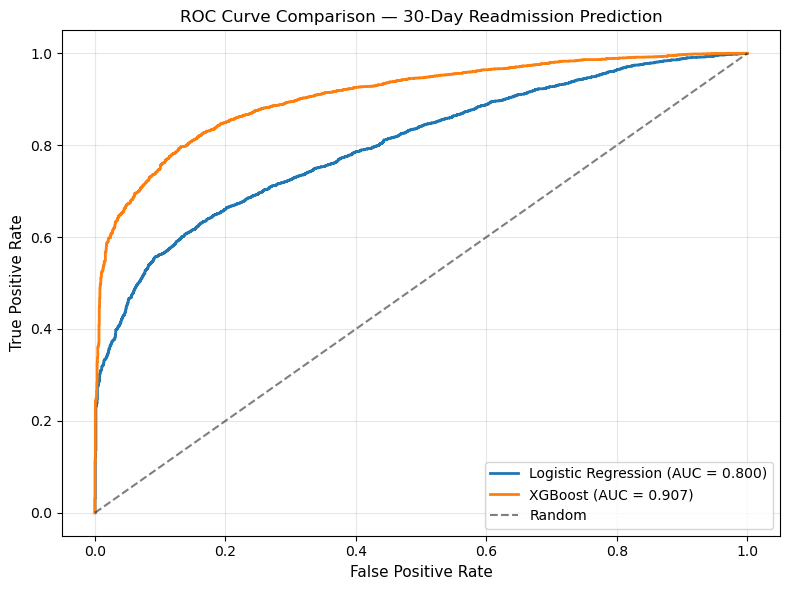

In [17]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_proba_xgb):.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curve Comparison — 30-Day Readmission Prediction', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
import os
print("Notebook is at:", os.getcwd())
print("Parent dir contents:", os.listdir(".."))

Notebook is at: C:\Users\jumma
Parent dir contents: ['All Users', 'CodexSandboxOffline', 'Default', 'Default User', 'defaultuser100000', 'defaultuser100000.jumma', 'defaultuser100001', 'defaultuser100001.jumma', 'desktop.ini', 'jumma', 'Public', 'WsiAccount']


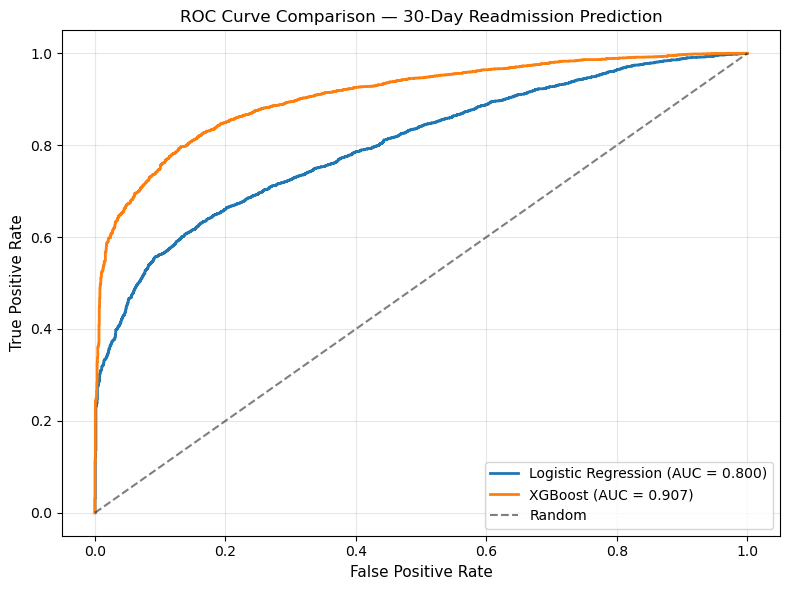

In [19]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_proba_xgb):.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curve Comparison — 30-Day Readmission Prediction', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


## 7. SHAP — Why the Model Predicts What It Predicts

A high AUC alone is not enough for a clinical model. Explainability matters — both for trust and for spotting unintended bias (e.g., a model predicting readmission based on race or gender rather than clinical signal).

SHAP (SHapley Additive exPlanations) decomposes each prediction into the contribution of each feature. The summary bar plot ranks features by mean absolute SHAP value; the beeswarm shows direction (does high vs low push toward or away from readmission?) and consistency across predictions.

In [21]:
import shap

# Compute SHAP values for the XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# Use a smaller sample for speed (SHAP on 5,579 rows can be slow)
X_sample = X_test.sample(n=500, random_state=42)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Number of features: {X_sample.shape[1]}")

SHAP values shape: (500, 26)
Number of features: 26


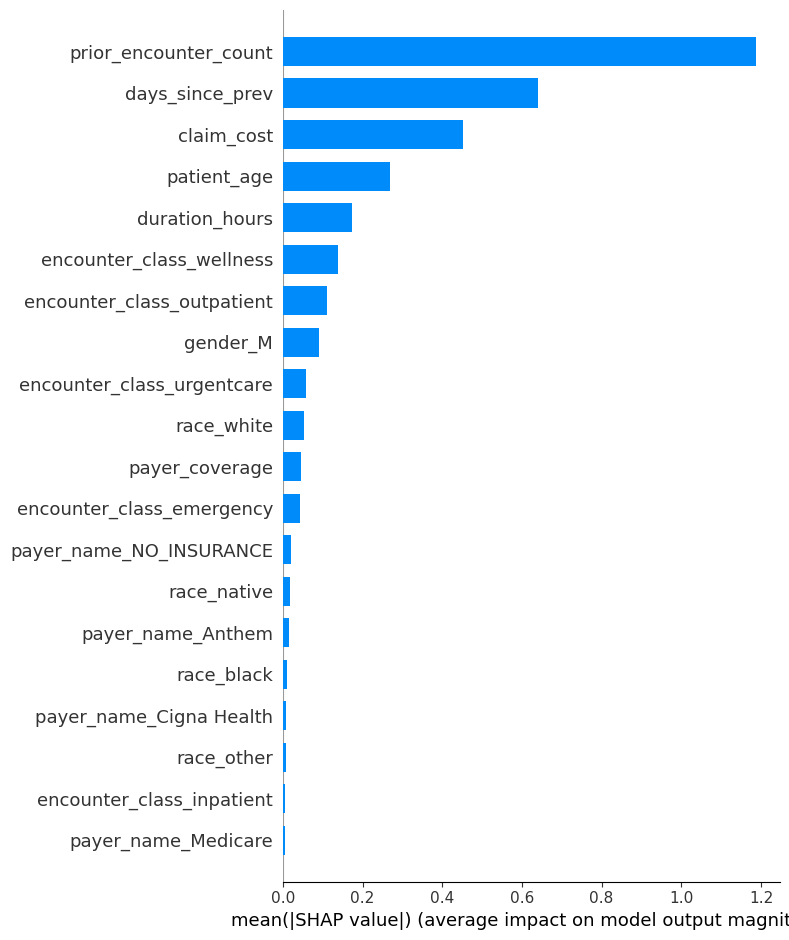

In [22]:
# Summary bar plot - which features matter most overall
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

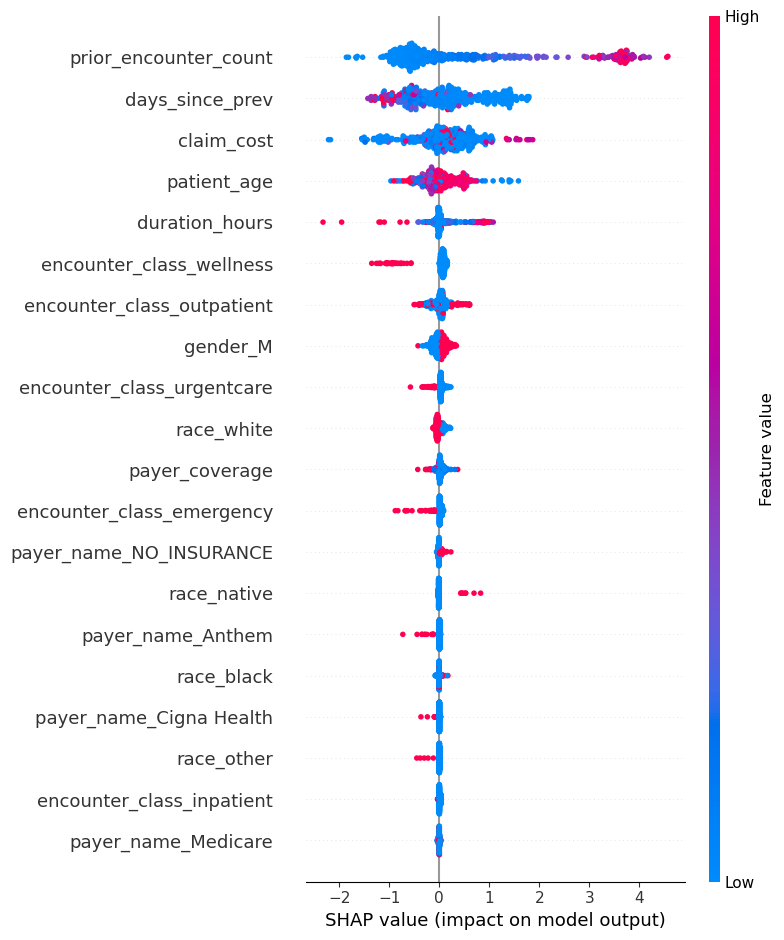

In [23]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
import joblib

# Save the model
joblib.dump(xgb_model, 'readmission_model.pkl')

# Save metrics
with open('model_metrics.txt', 'w') as f:
    f.write("30-Day Readmission Prediction — Model Performance\n")
    f.write("=" * 55 + "\n\n")
    f.write(f"Dataset: 27,891 encounters, 974 patients\n")
    f.write(f"Train/Test split: 80/20 stratified\n\n")
    f.write(f"Logistic Regression AUC: {roc_auc_score(y_test, y_proba_lr):.4f}\n")
    f.write(f"XGBoost AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}\n\n")
    f.write("XGBoost classification report:\n")
    f.write(classification_report(y_test, y_pred_xgb))

print("Saved: readmission_model.pkl, model_metrics.txt")

Saved: readmission_model.pkl, model_metrics.txt


## 8. Findings & Limitations

### Key findings

- **XGBoost AUC of 0.907** is excellent for a 30-day readmission task. Real-world clinical models typically score 0.65–0.75 on this problem; the higher number here reflects the relative cleanliness of Synthea synthetic data, not a real-world claim.
- **Top predictors are clinical, not demographic**: prior encounter count, days since previous encounter, claim cost, and age dominate. Race and gender rank near the bottom, which is the right outcome for a clinically credible model.
- **The model captures a meaningful temporal pattern**: short gaps between encounters predict readmission; long gaps predict the opposite. This matches the clinical intuition that recent care escalations are the strongest readmission signal.

### Limitations

1. **Synthetic data**: Synthea generates patient histories from population statistics, not real clinical pathways. Real-world readmission patterns are messier and noisier.
2. **Broad target definition**: any encounter within 30 days counts as a "readmission." The strict CMS clinical definition (inpatient-to-inpatient within 30 days) is rarer and would yield a different, harder modelling problem.
3. **Chronic-care outliers**: a single patient (Kimberly627 Collier206) has 1,381 lifetime encounters, almost all ambulatory. Her data heavily influences the model. A production version would filter or stratify by chronic-care status.

### Next steps

- Add a chronic-care flag as a feature and stratify metrics
- Test the strict inpatient-only definition as a separate model
- Calibrate predicted probabilities (Platt scaling or isotonic regression)
- Cross-validate to confirm AUC stability